In [8]:
import torch
from utils import generate_data, plot_comparison
from models import EulerSDE
from tqdm import tqdm
from loss import free_energy
from torch import nn

In [12]:
class MLPDrift(nn.Module):
    def __init__(self, d, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d + 1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, d)
        )

    def forward(self, t, x):
        t_emb = t.expand(x.shape[0], 1)
        return self.net(torch.cat([x, t_emb], dim=-1))

class StateDependentDiffusion(nn.Module):
    def __init__(self, d, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, hidden),
            nn.Tanh(),
            nn.Linear(hidden, d),
            nn.Softplus()  # чтобы σ > 0
        )

    def forward(self, t, x):
        return self.net(x)

class VariationalDrift(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.beta = nn.Parameter(torch.zeros(d))

    def forward(self, t, x):
        return self.beta.expand(x.shape[0], -1)

class ConstantDiffusion(nn.Module):
    def forward(self, t, x):
        return torch.ones_like(x)

In [ ]:
d = 10
A_true = torch.randn(d, d)
Y_data = generate_data(A_true, n_obs=10000, n_steps=64)

model = EulerSDE(
    d=d,
    model_drift=MLPDrift(d, hidden=64),
    variational_drift=VariationalDrift(d),
    diffusion=ConstantDiffusion(),
    method="euler"
)

In [ ]:
n_iters = 10000
batch_size = 128
n_steps = 32
losses = []

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for i in tqdm(range(n_iters)):
    optimizer.zero_grad()

    idx = torch.randint(0, len(Y_data), (batch_size,))
    y_batch = Y_data[idx]

    x1 = model(batch_size, n_steps)
    loss = free_energy(x1, y_batch, model.variational_drift.beta)

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

100%|██████████| 1000/1000 [00:13<00:00, 72.44it/s]


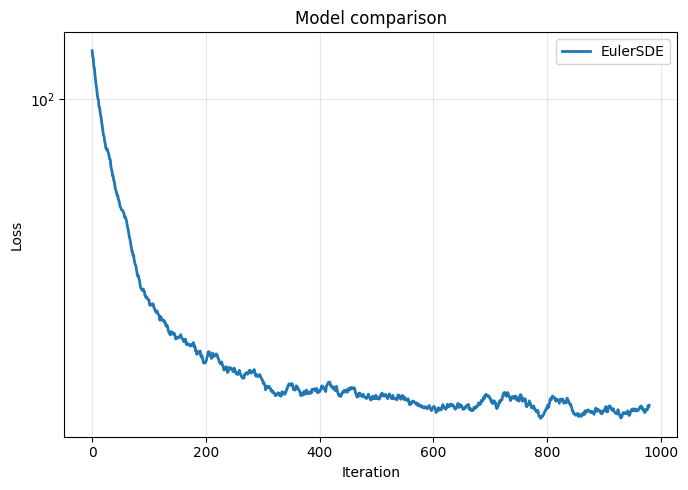

In [15]:
plot_comparison({"EulerSDE": losses})


In [16]:
model.eval()
with torch.no_grad():
    samples = model(batch_size=1000, n_steps=32)

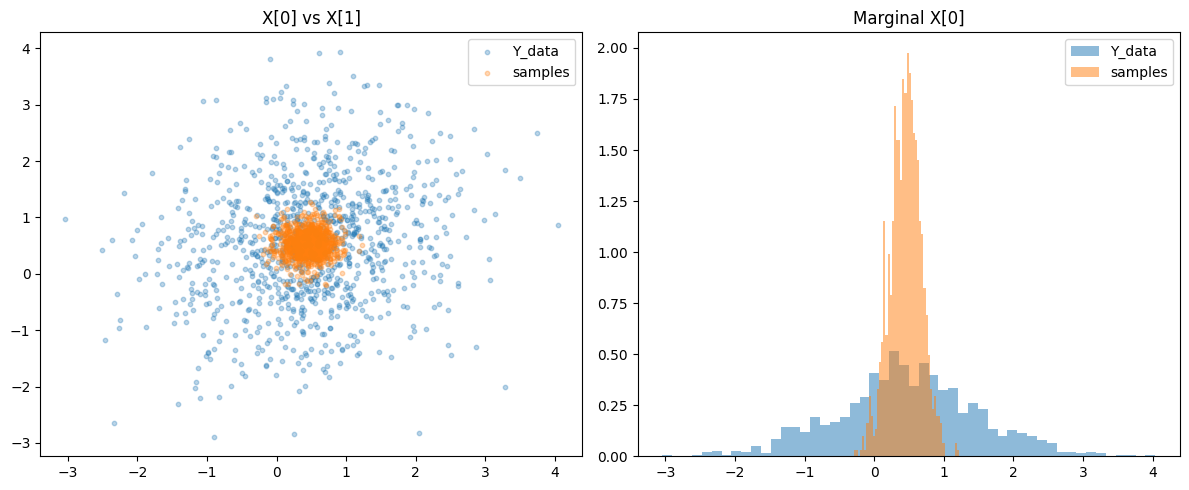

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(Y_data[:, 0].numpy(), Y_data[:, 1].numpy(), alpha=0.3, s=10, label="Y_data")
axes[0].scatter(samples[:, 0].numpy(), samples[:, 1].numpy(), alpha=0.3, s=10, label="samples")
axes[0].set_title("X[0] vs X[1]")
axes[0].legend()

axes[1].hist(Y_data[:, 0].numpy(), bins=50, alpha=0.5, label="Y_data", density=True)
axes[1].hist(samples[:, 0].numpy(), bins=50, alpha=0.5, label="samples", density=True)
axes[1].set_title("Marginal X[0]")
axes[1].legend()

plt.tight_layout()
plt.show()